## Load and Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = Path("../dataset")
dl_data_path = dataset_path / "dl_data"


# Load the data
X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

===== Datasets loaded successfully. =====


## Normalization

In [2]:
# Convert to float32
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Normalize using training data statistics
train_mean = X_train.mean()
train_std = X_train.std()

X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Channel Dimension

In [3]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== RESNET INPUT SHAPES =====")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== RESNET INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## Residual Block

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models


def residual_block(x, filters, kernel_size=3, stride=1):
    
    # Shortcut connection
    shortcut = x

    # First convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)
    
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=1,
        padding="same",
        use_bias=False
    )(x)
    
    x = layers.BatchNormalization()(x)

    # Match shortcut dimensions if necessary
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(
            filters=filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)
        
        shortcut = layers.BatchNormalization()(shortcut)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

## Create 1D ResNet

In [5]:
inputs = layers.Input(shape=(9000, 1))

# Initial convolution
x = layers.Conv1D(
    filters=32,
    kernel_size=7,
    strides=2,
    padding="same",
    use_bias=False
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.MaxPooling1D(
    pool_size=3,
    strides=2,
    padding="same"
)(x)


# Residual Stage 1
x = residual_block(x, filters=32)
x = residual_block(x, filters=32)


# Residual Stage 2
x = residual_block(x, filters=64, stride=2)
x = residual_block(x, filters=64)


# Residual Stage 3
x = residual_block(x, filters=128, stride=2)
x = residual_block(x, filters=128)


# Global feature extraction
x = layers.GlobalAveragePooling1D()(x)

# Fully connected layer
x = layers.Dense(
    64,
    activation="relu"
)(x)

# Output layer
outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="ECG_1D_ResNet"
)

model.summary()

Model: "ECG_1D_ResNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 4500, 32)     224         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 4500, 32)    128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 re_lu (ReLU)                   (None, 4500, 32)     0           ['batch_normalization

## Compile

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Callbacks

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_1d_resnet_unweighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

## Train

In [8]:
history = model.fit(
    X_train,
    y_train,
    
    validation_data=(
        X_validation,
        y_validation
    ),
    
    epochs=50,
    batch_size=32,
    
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    
    verbose=1
)

Epoch 1/50
187/187 [==============================] - ETA: 0s - loss: 0.9140 - accuracy: 0.6065
Epoch 1: val_loss improved from inf to 1.13311, saving model to best_1d_resnet_unweighted.keras
187/187 [==============================] - 91s 371ms/step - loss: 0.9140 - accuracy: 0.6065 - val_loss: 1.1331 - val_accuracy: 0.5481
Epoch 2/50
187/187 [==============================] - ETA: 0s - loss: 0.8034 - accuracy: 0.6478
Epoch 2: val_loss improved from 1.13311 to 1.01734, saving model to best_1d_resnet_unweighted.keras
187/187 [==============================] - 60s 322ms/step - loss: 0.8034 - accuracy: 0.6478 - val_loss: 1.0173 - val_accuracy: 0.4308
Epoch 3/50
187/187 [==============================] - ETA: 0s - loss: 0.7389 - accuracy: 0.6787
Epoch 3: val_loss improved from 1.01734 to 0.73203, saving model to best_1d_resnet_unweighted.keras
187/187 [==============================] - 59s 314ms/step - loss: 0.7389 - accuracy: 0.6787 - val_loss: 0.7320 - val_accuracy: 0.6779
Epoch 4/50
187

## Test

In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== 1D RESNET TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 1s 30ms/step - loss: 0.6402 - accuracy: 0.7477
===== 1D RESNET TEST RESULTS =====
Test Loss: 0.6402
Test Accuracy: 0.7477


## Prediction && Confusion Matrix

In [10]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("===== CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 2s 33ms/step
===== CONFUSION MATRIX =====
[[696  14  43   9]
 [ 16  79  16   2]
 [157  41 163   2]
 [ 21   0   2  19]]


## Graphic Confusion Matrix 

<Figure size 700x600 with 0 Axes>

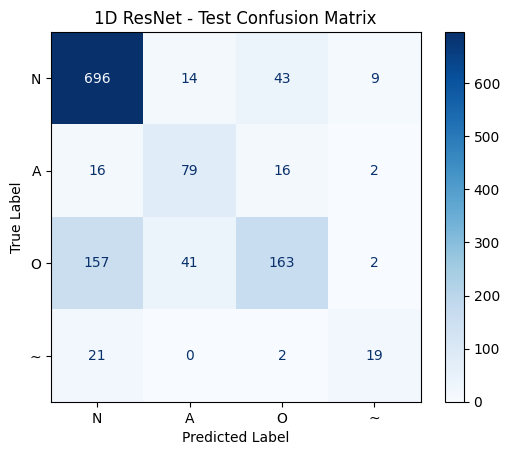

In [11]:
class_names = ["N", "A", "O", "~"]

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "1D ResNet - Test Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Classification Report

In [12]:
print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.7820    0.9134    0.8426       762
           A     0.5896    0.6991    0.6397       113
           O     0.7277    0.4490    0.5554       363
           ~     0.5938    0.4524    0.5135        42

    accuracy                         0.7477      1280
   macro avg     0.6733    0.6285    0.6378      1280
weighted avg     0.7434    0.7477    0.7324      1280



## Loss Plot

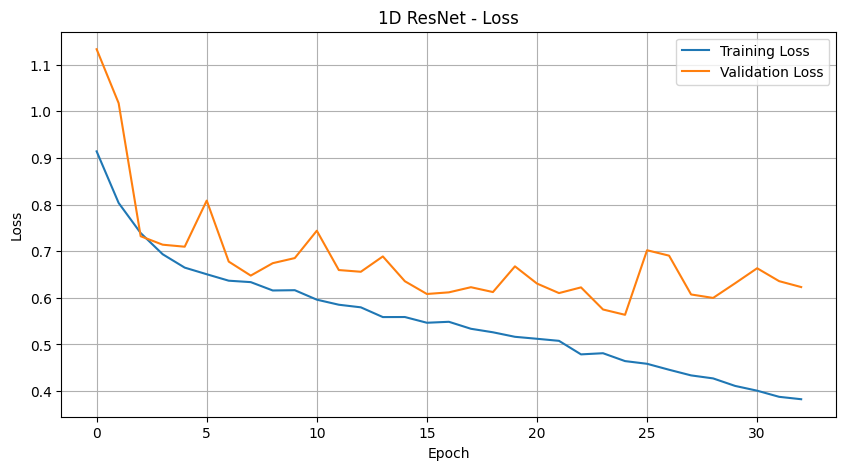

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("1D ResNet - Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

## Plot Accuracy

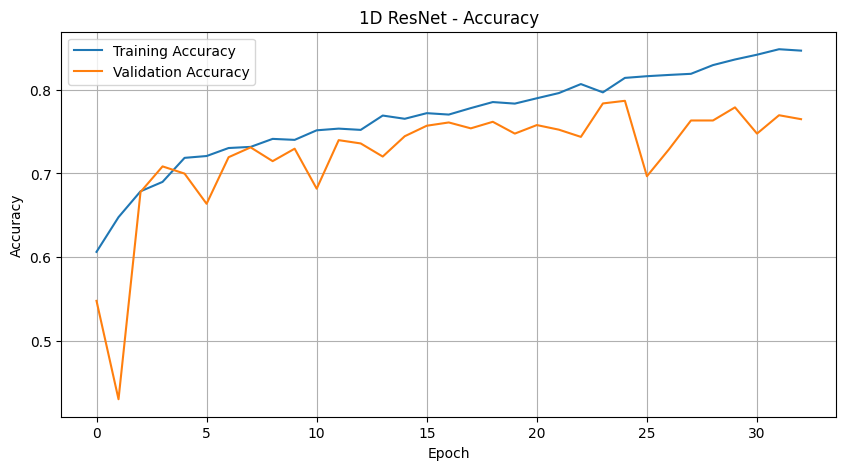

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("1D ResNet - Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()